# Modelo de proyección de transacciones por estación, día y hora

Versión ajustada con:

- validación cronológica,
- baseline simple por estación + día de semana + hora,
- búsqueda opcional de hiperparámetros,
- comparación entre modelo inicial, baseline y mejor modelo,
- análisis de error por estación, hora y día,
- proyección de una semana completa por `fecha + hora + estación`.

El objetivo del modelo es estimar algo como:

```text
lunes 2026-06-01, 8:00, Cocina caliente -> 12 transacciones estimadas
lunes 2026-06-01, 8:00, Parrilla -> 15 transacciones estimadas
```


## 1. Instalar dependencias, si hace falta

Ejecuta esta celda solo si tu entorno de Jupyter no tiene alguna librería instalada.

In [3]:
%pip install pandas numpy scikit-learn joblib matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Imports y configuración

Deja el notebook en la misma carpeta donde están los dos CSVs. Según tu captura, los nombres ya coinciden con esta configuración.

In [5]:
from __future__ import annotations

import re
import unicodedata
import warnings
from dataclasses import dataclass
from datetime import date, timedelta
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import randint, loguniform
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

# Archivos reales mostrados en tu carpeta de Jupyter
HISTORIAL_VENTAS_CSV = Path("historial_ventas_ficticio_ajustado_puntoycoma.csv")
ESTACIONES_CSV = Path("estaciones_por_item_menu_ficticio_ajustado_puntoycoma.csv")

# Si tus archivos usan punto y coma, esto queda en ";".
# La función de lectura también intenta detectar automáticamente el separador.
SEPARADOR_CSV = ";"

# Para consultas de ejemplo
FECHA_INICIO_PRUEBA = "2026-06-01"  # lunes 1 de junio de 2026
DIAS_A_PROYECTAR = 7

# Búsqueda de hiperparámetros
# Déjalo en True para buscar mejor modelo. Si quieres que el notebook corra rápido, ponlo en False.
EJECUTAR_BUSQUEDA_HIPERPARAMETROS = True

# Modo liviano: pocos intentos aleatorios para no trabar el computador.
# Si quieres más precisión y tienes buena máquina, puedes subir N_ITER_BUSQUEDA a 15 o 30.
N_ITER_BUSQUEDA = 8
CV_SPLITS = 2
CV_MIN_TEST_DAYS = 7
MAX_FILAS_BUSQUEDA = 30000
N_JOBS_BUSQUEDA = 1
RANDOM_STATE = 42

# Archivos de salida
RUTA_MODELO = Path("modelo_transacciones_estacion_hora.joblib")
RUTA_PROYECCION_SEMANA = Path("proyeccion_semana_estacion_hora.csv")
RUTA_COMPARACION_MODELOS = Path("comparacion_modelos.csv")
RUTA_EVALUACION_ESTACION = Path("evaluacion_por_estacion.csv")
RUTA_EVALUACION_HORA = Path("evaluacion_por_hora.csv")


## 3. Utilidades para leer, normalizar y preparar los datos

Estas funciones toleran nombres de columnas comunes en español, con o sin tildes. También intentan leer CSV con `;`, `,` o tabulador.

In [7]:
TARGET_COLUMN = "transacciones"
UNKNOWN_STATION = "SIN_ESTACION_MAPEADA"

COLUMN_ALIASES = {
    "fecha": {
        "dia_de_la_venta", "día_de_la_venta", "dia_venta", "fecha", "fecha_venta",
        "fecha_de_venta", "date", "fecha_y_hora", "fecha_hora",
    },
    "hora": {
        "hora_de_la_venta", "hora_venta", "hora", "hour", "hr",
    },
    "item_menu": {
        "item_del_menu", "item_del_menú", "item_menu", "producto", "item",
        "nombre_item", "nombre_del_item", "menu_item",
    },
    "cantidad": {
        "cantidad", "qty", "unidades", "quantity", "transacciones", "cant",
    },
    "estacion": {
        "estacion_afectada", "estación_afectada", "estacion", "estación",
        "station", "area", "area_de_preparacion", "área_de_preparación",
    },
}

DIAS_SEMANA_ES = {
    0: "lunes",
    1: "martes",
    2: "miércoles",
    3: "jueves",
    4: "viernes",
    5: "sábado",
    6: "domingo",
}


def normalize_column_name(name: str) -> str:
    without_bom = str(name).replace("\ufeff", "")
    normalized = unicodedata.normalize("NFKD", without_bom)
    ascii_name = "".join(ch for ch in normalized if not unicodedata.combining(ch))
    ascii_name = ascii_name.strip().lower()
    ascii_name = re.sub(r"[^a-z0-9]+", "_", ascii_name)
    return ascii_name.strip("_")


def rename_columns(frame: pd.DataFrame) -> pd.DataFrame:
    renamed = {}
    for column in frame.columns:
        normalized = normalize_column_name(column)
        canonical = next((target for target, aliases in COLUMN_ALIASES.items() if normalized in aliases), normalized)
        renamed[column] = canonical
    return frame.rename(columns=renamed)


def read_csv_auto(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No encontré el archivo: {path.resolve()}")

    # Primero probamos separadores típicos.
    for separator in (SEPARADOR_CSV, ";", ",", "\t"):
        try:
            frame = pd.read_csv(path, sep=separator, encoding="utf-8-sig")
            if len(frame.columns) > 1:
                return frame
        except UnicodeDecodeError:
            frame = pd.read_csv(path, sep=separator, encoding="latin-1")
            if len(frame.columns) > 1:
                return frame
        except Exception:
            pass

    # Último intento con inferencia de pandas.
    try:
        return pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, sep=None, engine="python", encoding="latin-1")


def parse_hour_series(values: pd.Series) -> pd.Series:
    # Soporta horas tipo 8, 08, 08:00, 08:15:00, etc.
    text = values.astype(str).str.strip()
    hour = pd.to_numeric(text.str.extract(r"^(\d{1,2})", expand=False), errors="coerce")
    return hour.where(hour.between(0, 23))


def parse_numeric_series(values: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(values, errors="coerce")
    # Si no pudo leer bien, intentamos formato español decimal con coma.
    if numeric.isna().mean() > 0.5:
        text = values.astype(str).str.strip()
        text = text.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
        numeric = pd.to_numeric(text, errors="coerce")
    return numeric


def require_columns(frame: pd.DataFrame, required: list[str], label: str) -> None:
    missing = [col for col in required if col not in frame.columns]
    if missing:
        raise ValueError(
            f"El archivo {label} no contiene estas columnas requeridas después de normalizar nombres: {missing}.\n"
            f"Columnas disponibles: {list(frame.columns)}"
        )


def listar_csvs_carpeta_actual() -> list[str]:
    return sorted(path.name for path in Path.cwd().glob("*.csv"))

## 4. Verificar que Jupyter ve los dos CSVs

Esta celda debe mostrar `Existe: True` para ambos archivos.

In [9]:
print("Carpeta actual de trabajo:", Path.cwd())
print("\nCSVs detectados en esta carpeta:")
for name in listar_csvs_carpeta_actual():
    print(" -", name)

for path in [HISTORIAL_VENTAS_CSV, ESTACIONES_CSV]:
    print("\nArchivo:", path)
    print("Existe:", path.exists())
    if path.exists():
        muestra = read_csv_auto(path).head(5)
        print("Columnas originales:", list(muestra.columns))
        display(muestra)

Carpeta actual de trabajo: C:\Users\andre

CSVs detectados en esta carpeta:
 - df_completo_A.csv
 - df_completo_B.csv
 - df_zonal_completo_filtrado.csv
 - estaciones_por_item_menu_ficticio_ajustado_puntoycoma.csv
 - historial_ventas_ficticio_ajustado_puntoycoma.csv

Archivo: historial_ventas_ficticio_ajustado_puntoycoma.csv
Existe: True
Columnas originales: ['Día de la venta', 'Hora de la venta', 'Item del menú', 'Cantidad', 'Observaciones']


,Día de la venta,Hora de la venta,Item del menú,Cantidad,Observaciones
0,2024-01-01,07:15,Bowl de yogurt y granola,1,Feriado
1,2024-01-01,07:15,Capuchino,1,Feriado
2,2024-01-01,07:20,Croissant,1,Feriado
3,2024-01-01,07:25,Bowl vegetariano,1,Feriado
4,2024-01-01,07:25,Café americano,4,Feriado



Archivo: estaciones_por_item_menu_ficticio_ajustado_puntoycoma.csv
Existe: True
Columnas originales: ['Item del menú', 'Estación afectada', 'Observaciones']


,Item del menú,Estación afectada,Observaciones
0,Café americano,Café,preparación de bebida
1,Café americano,Caja,registro y cobro de la venta
2,Café latte,Café,preparación de bebida
3,Café latte,Caja,registro y cobro de la venta
4,Capuchino,Café,preparación de bebida


## 5. Cargar ventas, mapear items a estaciones y crear el dataset estación-hora

La variable objetivo del modelo será:

**transacciones = suma de `cantidad` por cada `fecha + hora + estacion`**

Importante: si un item del menú afecta varias estaciones, una misma venta se cuenta en cada estación afectada. Esto es útil para estimar carga operativa por estación.

In [11]:
@dataclass(frozen=True)
class DatasetEstacionHora:
    frame: pd.DataFrame
    ventas_normalizadas: pd.DataFrame
    estaciones_normalizadas: pd.DataFrame
    estaciones: list[str]
    horas: list[int]
    fecha_inicio: date
    fecha_fin: date
    items_sin_estacion: list[str]


def normalizar_ventas(raw: pd.DataFrame) -> pd.DataFrame:
    frame = rename_columns(raw)
    require_columns(frame, ["fecha", "hora", "item_menu"], "historial de ventas")

    result = frame[["fecha", "hora", "item_menu"] + (["cantidad"] if "cantidad" in frame.columns else [])].copy()
    result["fecha"] = pd.to_datetime(result["fecha"], errors="coerce")
    result["hora"] = parse_hour_series(result["hora"])
    result["item_menu"] = result["item_menu"].astype(str).str.strip()

    if "cantidad" in result.columns:
        result["cantidad"] = parse_numeric_series(result["cantidad"])
    else:
        # Si no hay columna de cantidad, cada fila cuenta como 1 transacción.
        result["cantidad"] = 1.0

    result = result.dropna(subset=["fecha", "hora", "item_menu", "cantidad"])
    result = result[(result["item_menu"] != "") & (result["cantidad"] >= 0)]
    result["hora"] = result["hora"].astype(int)
    result["fecha"] = result["fecha"].dt.normalize()

    if result.empty:
        raise ValueError("El historial de ventas no contiene filas válidas para entrenamiento.")

    return result


def normalizar_estaciones(raw: pd.DataFrame) -> pd.DataFrame:
    frame = rename_columns(raw)
    require_columns(frame, ["item_menu", "estacion"], "estaciones por item")

    result = frame[["item_menu", "estacion"]].copy()
    result["item_menu"] = result["item_menu"].astype(str).str.strip()
    result["estacion"] = result["estacion"].astype(str).str.strip()
    result = result[(result["item_menu"] != "") & (result["estacion"] != "")]
    result = result.drop_duplicates()

    if result.empty:
        raise ValueError("El archivo de estaciones por item no contiene filas válidas.")

    return result


def add_calendar_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["fecha"] = pd.to_datetime(result["fecha"])
    iso = result["fecha"].dt.isocalendar()

    result["hora"] = result["hora"].astype(int)
    result["estacion"] = result["estacion"].astype(str)

    result["dia_semana"] = result["fecha"].dt.weekday.astype(int)
    result["dia_semana_nombre"] = result["dia_semana"].map(DIAS_SEMANA_ES)
    result["dia_mes"] = result["fecha"].dt.day.astype(int)
    result["mes"] = result["fecha"].dt.month.astype(int)
    result["semana_anio"] = iso.week.astype(int)
    result["dia_anio"] = result["fecha"].dt.dayofyear.astype(int)
    result["trimestre"] = result["fecha"].dt.quarter.astype(int)
    result["es_fin_semana"] = result["dia_semana"].isin([5, 6]).astype(int)
    result["es_inicio_mes"] = (result["dia_mes"] <= 5).astype(int)
    result["es_fin_mes"] = result["fecha"].dt.is_month_end.astype(int)

    # Variables cíclicas para que el modelo entienda continuidad de horas/días.
    result["hora_sin"] = np.sin(2 * np.pi * result["hora"] / 24)
    result["hora_cos"] = np.cos(2 * np.pi * result["hora"] / 24)
    result["dia_semana_sin"] = np.sin(2 * np.pi * result["dia_semana"] / 7)
    result["dia_semana_cos"] = np.cos(2 * np.pi * result["dia_semana"] / 7)
    result["mes_sin"] = np.sin(2 * np.pi * result["mes"] / 12)
    result["mes_cos"] = np.cos(2 * np.pi * result["mes"] / 12)

    return result


def completar_grid_estacion_hora(grouped: pd.DataFrame, fechas: pd.DatetimeIndex, horas: list[int], estaciones: list[str]) -> pd.DataFrame:
    full_index = pd.MultiIndex.from_product(
        [fechas, horas, estaciones],
        names=["fecha", "hora", "estacion"],
    )
    completed = (
        grouped.set_index(["fecha", "hora", "estacion"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )
    completed[TARGET_COLUMN] = completed[TARGET_COLUMN].astype(float)
    return completed


def cargar_dataset_estacion_hora(historial_path: Path, estaciones_path: Path) -> DatasetEstacionHora:
    ventas_raw = read_csv_auto(historial_path)
    estaciones_raw = read_csv_auto(estaciones_path)

    ventas = normalizar_ventas(ventas_raw)
    estaciones_map = normalizar_estaciones(estaciones_raw)

    # Una venta se asigna a la estación o estaciones afectadas por el item.
    expanded = ventas.merge(estaciones_map, how="left", on="item_menu")
    missing_mask = expanded["estacion"].isna()
    items_sin_estacion = sorted(expanded.loc[missing_mask, "item_menu"].dropna().unique().tolist())
    expanded["estacion"] = expanded["estacion"].fillna(UNKNOWN_STATION)

    # Cantidad representa transacciones/carga para la estación.
    expanded["transacciones_estacion"] = expanded["cantidad"].astype(float)

    grouped = (
        expanded.groupby(["fecha", "hora", "estacion"], as_index=False)["transacciones_estacion"]
        .sum()
        .rename(columns={"transacciones_estacion": TARGET_COLUMN})
    )

    fecha_inicio = ventas["fecha"].min().date()
    fecha_fin = ventas["fecha"].max().date()
    fechas = pd.date_range(fecha_inicio, fecha_fin, freq="D")
    horas = sorted(int(hour) for hour in ventas["hora"].unique().tolist())

    estaciones = sorted(str(station) for station in estaciones_map["estacion"].unique())
    if items_sin_estacion and UNKNOWN_STATION not in estaciones:
        estaciones.append(UNKNOWN_STATION)
    estaciones = sorted(estaciones)

    frame = completar_grid_estacion_hora(grouped, fechas, horas, estaciones)
    frame = add_calendar_features(frame)

    return DatasetEstacionHora(
        frame=frame,
        ventas_normalizadas=ventas,
        estaciones_normalizadas=estaciones_map,
        estaciones=estaciones,
        horas=horas,
        fecha_inicio=fecha_inicio,
        fecha_fin=fecha_fin,
        items_sin_estacion=items_sin_estacion,
    )


dataset = cargar_dataset_estacion_hora(HISTORIAL_VENTAS_CSV, ESTACIONES_CSV)

print("Rango histórico:", dataset.fecha_inicio, "a", dataset.fecha_fin)
print("Horas detectadas:", dataset.horas)
print("Estaciones detectadas:", dataset.estaciones)
print("Filas de ventas normalizadas:", len(dataset.ventas_normalizadas))
print("Filas de mapeo item-estación:", len(dataset.estaciones_normalizadas))
print("Filas del dataset de entrenamiento estación-hora:", len(dataset.frame))

if dataset.items_sin_estacion:
    print("\nItems sin estación mapeada, se enviaron a", UNKNOWN_STATION)
    print(dataset.items_sin_estacion[:30])

display(dataset.frame.head(10))

Rango histórico: 2024-01-01 a 2025-06-30
Horas detectadas: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Estaciones detectadas: ['Bebidas', 'Café', 'Caja', 'Cocina caliente', 'Cocina fría', 'Ensamble', 'Freidora', 'Horno', 'Panadería', 'Parrilla', 'Pasta', 'Pastelería', 'Plancha', 'Postres fríos', 'Salsas']
Filas de ventas normalizadas: 208874
Filas de mapeo item-estación: 89
Filas del dataset de entrenamiento estación-hora: 123075


,fecha,hora,estacion,transacciones,dia_semana,dia_semana_nombre,dia_mes,mes,semana_anio,dia_anio,trimestre,es_fin_semana,es_inicio_mes,es_fin_mes,hora_sin,hora_cos,dia_semana_sin,dia_semana_cos,mes_sin,mes_cos
0,2024-01-01,7,Bebidas,6.0,0,lunes,1,1,1,1,1,0,1,0,0.965926,-0.258819,0.0,1.0,0.5,0.866025
1,2024-01-01,7,Café,7.0,0,lunes,1,1,1,1,1,0,1,0,0.965926,-0.258819,0.0,1.0,0.5,0.866025
2,2024-01-01,7,Caja,21.0,0,lunes,1,1,1,1,1,0,1,0,0.965926,-0.258819,0.0,1.0,0.5,0.866025
3,2024-01-01,7,Cocina caliente,4.0,0,lunes,1,1,1,1,1,0,1,0,0.965926,-0.258819,0.0,1.0,0.5,0.866025
4,2024-01-01,7,Cocina fría,4.0,0,lunes,1,1,1,1,1,0,1,0,0.965926,-0.258819,0.0,1.0,0.5,0.866025
5,2024-01-01,7,Ensamble,1.0,0,lunes,1,1,1,1,1,0,1,0,0.965926,-0.258819,0.0,1.0,0.5,0.866025
6,2024-01-01,7,Freidora,0.0,0,lunes,1,1,1,1,1,0,1,0,0.965926,-0.258819,0.0,1.0,0.5,0.866025
7,2024-01-01,7,Horno,0.0,0,lunes,1,1,1,1,1,0,1,0,0.965926,-0.258819,0.0,1.0,0.5,0.866025
8,2024-01-01,7,Panadería,1.0,0,lunes,1,1,1,1,1,0,1,0,0.965926,-0.258819,0.0,1.0,0.5,0.866025
9,2024-01-01,7,Parrilla,0.0,0,lunes,1,1,1,1,1,0,1,0,0.965926,-0.258819,0.0,1.0,0.5,0.866025


## 6. Vista rápida de transacciones reales por estación, día y hora

Esto permite validar que el dataset ya está en la granularidad correcta: `fecha + hora + estacion`.

In [13]:
resumen_estacion = (
    dataset.frame.groupby("estacion", as_index=False)[TARGET_COLUMN]
    .sum()
    .sort_values(TARGET_COLUMN, ascending=False)
)
print("Transacciones históricas por estación:")
display(resumen_estacion)

print("Ejemplo de matriz por hora para la última fecha del histórico:")
ultima_fecha = dataset.frame["fecha"].max()
matriz_ultima_fecha = (
    dataset.frame[dataset.frame["fecha"] == ultima_fecha]
    .pivot_table(index="hora", columns="estacion", values=TARGET_COLUMN, aggfunc="sum", fill_value=0)
)
display(matriz_ultima_fecha)

Transacciones históricas por estación:


,estacion,transacciones
2,Caja,1221827.0
5,Ensamble,540394.0
3,Cocina caliente,353983.0
4,Cocina fría,296756.0
0,Bebidas,228892.0
6,Freidora,189478.0
9,Parrilla,147921.0
1,Café,140582.0
12,Plancha,101782.0
10,Pasta,82868.0


Ejemplo de matriz por hora para la última fecha del histórico:


estacion,Bebidas,Café,Caja,Cocina caliente,Cocina fría,Ensamble,Freidora,Horno,Panadería,Parrilla,Pasta,Pastelería,Plancha,Postres fríos,Salsas
hora,,,,,,,,,,,,,,,
7,11.0,14.0,46.0,6.0,10.0,5.0,1.0,0.0,6.0,0.0,2.0,0.0,4.0,0.0,0.0
8,18.0,47.0,94.0,9.0,9.0,0.0,1.0,0.0,10.0,0.0,1.0,0.0,13.0,0.0,0.0
9,19.0,67.0,137.0,16.0,19.0,9.0,3.0,2.0,11.0,3.0,0.0,0.0,25.0,1.0,0.0
10,25.0,33.0,103.0,16.0,22.0,19.0,3.0,1.0,10.0,3.0,3.0,1.0,10.0,0.0,0.0
11,33.0,22.0,156.0,34.0,33.0,62.0,29.0,3.0,11.0,23.0,6.0,3.0,14.0,0.0,2.0
12,39.0,9.0,259.0,83.0,88.0,150.0,62.0,5.0,2.0,39.0,22.0,10.0,17.0,2.0,2.0
13,47.0,0.0,269.0,108.0,110.0,183.0,55.0,4.0,2.0,45.0,25.0,4.0,28.0,4.0,2.0
14,52.0,6.0,245.0,95.0,77.0,141.0,59.0,4.0,0.0,43.0,30.0,10.0,21.0,0.0,4.0
15,25.0,5.0,107.0,31.0,26.0,58.0,25.0,2.0,3.0,23.0,12.0,3.0,8.0,3.0,0.0


## 7. Entrenar el modelo

El modelo usa variables de calendario, hora y estación. La validación se hace de forma cronológica: los últimos días del histórico se reservan para validar.

In [15]:
FEATURE_NUMERIC_COLUMNS = [
    "hora", "dia_semana", "dia_mes", "mes", "semana_anio", "dia_anio", "trimestre",
    "es_fin_semana", "es_inicio_mes", "es_fin_mes",
    "hora_sin", "hora_cos", "dia_semana_sin", "dia_semana_cos", "mes_sin", "mes_cos",
]
FEATURE_CATEGORICAL_COLUMNS = ["estacion"]
FEATURE_COLUMNS = FEATURE_NUMERIC_COLUMNS + FEATURE_CATEGORICAL_COLUMNS


def select_features(frame: pd.DataFrame) -> pd.DataFrame:
    return frame[FEATURE_COLUMNS].copy()


def chronological_split(frame: pd.DataFrame, validation_fraction: float = 0.2) -> tuple[pd.DataFrame, pd.DataFrame]:
    ordered = frame.sort_values(["fecha", "hora", "estacion"]).reset_index(drop=True)
    unique_dates = sorted(ordered["fecha"].dt.date.unique().tolist())
    if len(unique_dates) < 5:
        return ordered, ordered

    validation_days = max(1, int(round(len(unique_dates) * validation_fraction)))
    validation_dates = set(unique_dates[-validation_days:])
    validation_mask = ordered["fecha"].dt.date.isin(validation_dates)

    train_frame = ordered.loc[~validation_mask].copy()
    validation_frame = ordered.loc[validation_mask].copy()

    if train_frame.empty or validation_frame.empty:
        return ordered, ordered
    return train_frame, validation_frame


def make_one_hot_encoder() -> OneHotEncoder:
    # Compatibilidad entre versiones de scikit-learn.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_pipeline_con_estimador(estimator) -> Pipeline:
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), FEATURE_NUMERIC_COLUMNS),
            ("categorical", make_one_hot_encoder(), FEATURE_CATEGORICAL_COLUMNS),
        ],
        remainder="drop",
        sparse_threshold=0,
    )

    # log1p/expm1 ayuda con conteos y evita predicciones negativas extremas.
    model = TransformedTargetRegressor(
        regressor=estimator,
        func=np.log1p,
        inverse_func=np.expm1,
    )

    return Pipeline([
        ("features", preprocessor),
        ("model", model),
    ])


def build_pipeline() -> Pipeline:
    return build_pipeline_con_estimador(Ridge(alpha=1.0))


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator > 0
    if not mask.any():
        return 0.0
    return float(np.mean(2.0 * np.abs(y_pred[mask] - y_true[mask]) / denominator[mask]))


def wmape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        return 0.0
    return float(np.sum(np.abs(y_true - y_pred)) / denominator)


def evaluar_modelo(modelo: Pipeline, validation_frame: pd.DataFrame) -> dict[str, float]:
    y_true = validation_frame[TARGET_COLUMN].astype(float).to_numpy()
    y_pred = modelo.predict(select_features(validation_frame)).astype(float)
    y_pred = np.clip(y_pred, a_min=0, a_max=None)

    metrics = {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "wmape": wmape(y_true, y_pred),
        "smape": smape(y_true, y_pred),
    }
    try:
        metrics["r2"] = r2_score(y_true, y_pred)
    except ValueError:
        metrics["r2"] = 0.0

    return {key: round(float(value), 6) for key, value in metrics.items()}


train_frame, validation_frame = chronological_split(dataset.frame, validation_fraction=0.2)
modelo = build_pipeline()
modelo.fit(select_features(train_frame), train_frame[TARGET_COLUMN])
metricas = evaluar_modelo(modelo, validation_frame)

# Nombres explícitos para poder comparar contra baseline y contra búsqueda de hiperparámetros.
modelo_inicial = modelo
metricas_modelo_inicial = metricas.copy()
modelo_final = modelo_inicial
metricas_modelo_final = metricas_modelo_inicial.copy()

print("Filas entrenamiento:", len(train_frame))
print("Filas validación:", len(validation_frame))
print("Fechas validación:", validation_frame["fecha"].min().date(), "a", validation_frame["fecha"].max().date())
print("Métricas modelo inicial Ridge:")
display(pd.DataFrame([metricas_modelo_inicial]))


Filas entrenamiento: 98550
Filas validación: 24525
Fechas validación: 2025-03-14 a 2025-06-30
Métricas modelo inicial Ridge:


,mae,rmse,wmape,smape,r2
0,14.994506,29.105981,0.487444,0.757617,0.670804


## 8. Comparación rápida: real vs predicción en validación

La tabla permite revisar ejemplos a nivel `fecha + hora + estación`.

In [17]:
validacion = validation_frame[["fecha", "dia_semana_nombre", "hora", "estacion", TARGET_COLUMN]].copy()
validacion["prediccion"] = np.clip(modelo_inicial.predict(select_features(validation_frame)), 0, None)
validacion["prediccion_redondeada"] = validacion["prediccion"].round().astype(int)
validacion["error_abs"] = (validacion[TARGET_COLUMN] - validacion["prediccion"]).abs()

print("Muestra de validación por estación-hora usando el modelo inicial:")
display(validacion.sort_values(["fecha", "hora", "estacion"]).head(30))

print("Top errores absolutos del modelo inicial:")
display(validacion.sort_values("error_abs", ascending=False).head(20))


Muestra de validación por estación-hora usando el modelo inicial:


,fecha,dia_semana_nombre,hora,estacion,transacciones,prediccion,prediccion_redondeada,error_abs
98550,2025-03-14,viernes,7,Bebidas,7.0,8.689090,9,1.689090
98551,2025-03-14,viernes,7,Café,19.0,3.268554,3,15.731446
98552,2025-03-14,viernes,7,Caja,52.0,47.282730,47,4.717270
98553,2025-03-14,viernes,7,Cocina caliente,8.0,11.100549,11,3.100549
98554,2025-03-14,viernes,7,Cocina fría,9.0,9.339428,9,0.339428
98555,2025-03-14,viernes,7,Ensamble,2.0,13.788456,14,11.788456
98556,2025-03-14,viernes,7,Freidora,4.0,4.556176,5,0.556176
98557,2025-03-14,viernes,7,Horno,0.0,1.086675,1,1.086675
98558,2025-03-14,viernes,7,Panadería,4.0,0.305057,0,3.694943
98559,2025-03-14,viernes,7,Parrilla,0.0,3.568110,4,3.568110


Top errores absolutos del modelo inicial:


,fecha,dia_semana_nombre,hora,estacion,transacciones,prediccion,prediccion_redondeada,error_abs
103367,2025-04-04,viernes,13,Caja,494.0,221.907668,222,272.092332
117542,2025-06-06,viernes,13,Caja,482.0,211.563155,212,270.436845
117545,2025-06-06,viernes,13,Ensamble,313.0,64.105696,64,248.894304
103370,2025-04-04,viernes,13,Ensamble,308.0,67.274104,67,240.725896
122267,2025-06-27,viernes,13,Caja,439.0,208.385603,208,230.614397
119117,2025-06-13,viernes,13,Caja,434.0,210.498649,210,223.501351
113042,2025-05-17,sábado,13,Caja,447.0,226.573681,227,220.426319
100307,2025-03-21,viernes,19,Caja,355.0,140.610573,141,214.389427
109892,2025-05-03,sábado,13,Caja,442.0,227.948402,228,214.051598
109670,2025-05-02,viernes,13,Ensamble,277.0,66.043538,66,210.956462


## 8A. Baseline simple: promedio histórico por estación, día de semana y hora

Antes de confiar en un modelo de machine learning, conviene compararlo contra una regla sencilla.

Este baseline predice usando el promedio histórico de:

```text
estación + día de semana + hora
```

Si el modelo no mejora este baseline, todavía no está aportando suficiente valor.

In [19]:
def evaluar_predicciones(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), a_min=0, a_max=None)

    metrics = {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "wmape": wmape(y_true, y_pred),
        "smape": smape(y_true, y_pred),
    }
    try:
        metrics["r2"] = r2_score(y_true, y_pred)
    except ValueError:
        metrics["r2"] = 0.0
    return {key: round(float(value), 6) for key, value in metrics.items()}


baseline = (
    train_frame
    .groupby(["estacion", "dia_semana", "hora"], as_index=False)[TARGET_COLUMN]
    .mean()
    .rename(columns={TARGET_COLUMN: "prediccion_baseline"})
)

validacion_baseline = validation_frame.merge(
    baseline,
    on=["estacion", "dia_semana", "hora"],
    how="left",
)

promedio_global = train_frame[TARGET_COLUMN].mean()
validacion_baseline["prediccion_baseline"] = validacion_baseline["prediccion_baseline"].fillna(promedio_global)

metricas_baseline = evaluar_predicciones(
    validacion_baseline[TARGET_COLUMN],
    validacion_baseline["prediccion_baseline"],
)

comparacion_modelos = pd.DataFrame([
    {"modelo": "baseline_promedio_estacion_dia_hora", **metricas_baseline},
    {"modelo": "modelo_inicial_ridge", **metricas_modelo_inicial},
])

comparacion_modelos["wmape_pct"] = comparacion_modelos["wmape"] * 100
comparacion_modelos["smape_pct"] = comparacion_modelos["smape"] * 100

display(comparacion_modelos.sort_values("mae"))


,modelo,mae,rmse,wmape,smape,r2,wmape_pct,smape_pct
0,baseline_promedio_estacion_dia_hora,5.221233,10.160306,0.169733,0.428606,0.959885,16.9733,42.8606
1,modelo_inicial_ridge,14.994506,29.105981,0.487444,0.757617,0.670804,48.7444,75.7617


## 8B. Búsqueda de hiperparámetros con validación temporal

Esta búsqueda prueba varios modelos y configuraciones.

Importante: la validación no es aleatoria. Se hace por fechas completas para evitar que el modelo aprenda con datos del futuro.

Modelos probados:

- `Ridge`: rápido y estable.
- `RandomForestRegressor`: captura relaciones no lineales.
- `ExtraTreesRegressor`: parecido a Random Forest, a veces mejor en datos tabulares.
- `HistGradientBoostingRegressor`: suele funcionar bien en patrones tabulares y puede capturar interacciones.

### Modo liviano de búsqueda

Esta versión usa una búsqueda aleatoria corta para evitar que el computador se trabe:

- `N_ITER_BUSQUEDA = 8`: solo 8 combinaciones aleatorias.
- `CV_SPLITS = 2`: dos cortes temporales de validación.
- `MAX_FILAS_BUSQUEDA = 30000`: busca hiperparámetros sobre una muestra reciente.
- `N_JOBS_BUSQUEDA = 1`: evita usar todos los núcleos del computador.

Después de encontrar la mejor configuración, el notebook reentrena ese modelo usando todo el conjunto de entrenamiento.

In [22]:
class DateBasedTimeSeriesSplit:
    # Split temporal por fechas completas.
    # Evita que una parte del mismo día quede en entrenamiento y otra en validación.
    # Esto es importante porque estamos proyectando fechas futuras.
    #
    # IMPORTANTE:
    # Scikit-learn espera índices POSICIONALES dentro del DataFrame que recibe en fit.
    # Por eso usamos np.flatnonzero(mask) y no X.index[mask].
    # Si usamos X.index después de hacer .tail() o filtros, pueden quedar índices antiguos
    # y aparece el error: IndexError: indices are out-of-bounds.

    def __init__(self, n_splits: int = 2, min_test_days: int = 7):
        self.n_splits = n_splits
        self.min_test_days = min_test_days

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        X_local = X.reset_index(drop=True).copy()
        fechas_col = pd.to_datetime(X_local["fecha"]).dt.date
        fechas = pd.Series(fechas_col.unique()).sort_values().to_numpy()

        if len(fechas) < self.n_splits + 2:
            raise ValueError("No hay suficientes fechas para hacer validación temporal.")

        test_size = max(self.min_test_days, len(fechas) // (self.n_splits + 3))

        for i in range(self.n_splits):
            test_start = len(fechas) - test_size * (self.n_splits - i)
            test_end = test_start + test_size

            if test_start <= 0:
                continue

            train_dates = set(fechas[:test_start])
            test_dates = set(fechas[test_start:test_end])

            train_mask = fechas_col.isin(train_dates).to_numpy()
            test_mask = fechas_col.isin(test_dates).to_numpy()

            train_idx = np.flatnonzero(train_mask)
            test_idx = np.flatnonzero(test_mask)

            if len(train_idx) == 0 or len(test_idx) == 0:
                continue

            yield train_idx, test_idx


# Búsqueda liviana:
# - Ridge: muy rápido.
# - ExtraTrees: modelo no lineal, pero con pocos árboles.
# - HistGradientBoosting: buena opción tabular y relativamente eficiente.
# Se quitó RandomForest porque suele ser más pesado en esta configuración.
param_distributions = [
    {
        "model__regressor": [Ridge()],
        "model__regressor__alpha": loguniform(0.01, 100),
    },
    {
        "model__regressor": [ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS_BUSQUEDA)],
        "model__regressor__n_estimators": randint(50, 160),
        "model__regressor__max_depth": [6, 10, 15, None],
        "model__regressor__min_samples_leaf": randint(2, 20),
        "model__regressor__max_features": ["sqrt", 0.5, 0.8],
    },
    {
        "model__regressor": [HistGradientBoostingRegressor(random_state=RANDOM_STATE)],
        "model__regressor__max_iter": randint(60, 180),
        "model__regressor__learning_rate": loguniform(0.03, 0.2),
        "model__regressor__max_leaf_nodes": randint(15, 50),
        "model__regressor__min_samples_leaf": randint(15, 80),
        "model__regressor__l2_regularization": loguniform(0.001, 3),
    },
]

if EJECUTAR_BUSQUEDA_HIPERPARAMETROS:
    # Para que la búsqueda no sea pesada, se usa una muestra reciente del entrenamiento.
    # El modelo final ganador se re-entrena después usando todo el train_frame.
    train_frame_busqueda = (
        train_frame
        .sort_values(["fecha", "hora", "estacion"])
        .tail(MAX_FILAS_BUSQUEDA)
        .reset_index(drop=True)
        .copy()
    )

    print("Filas usadas en búsqueda:", len(train_frame_busqueda), "de", len(train_frame))
    print("Iteraciones aleatorias:", N_ITER_BUSQUEDA)
    print("Splits temporales:", CV_SPLITS)
    print("Índice reiniciado para búsqueda:", train_frame_busqueda.index.min(), "a", train_frame_busqueda.index.max())

    pipeline_busqueda = build_pipeline_con_estimador(Ridge())
    cv_temporal = DateBasedTimeSeriesSplit(
        n_splits=CV_SPLITS,
        min_test_days=CV_MIN_TEST_DAYS,
    )

    busqueda = RandomizedSearchCV(
        estimator=pipeline_busqueda,
        param_distributions=param_distributions,
        n_iter=N_ITER_BUSQUEDA,
        scoring="neg_mean_absolute_error",
        cv=cv_temporal,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS_BUSQUEDA,
        verbose=1,
    )

    # Pasamos el frame completo de búsqueda porque el splitter necesita la columna fecha.
    # El pipeline solo usará las columnas definidas en FEATURE_COLUMNS.
    busqueda.fit(train_frame_busqueda, train_frame_busqueda[TARGET_COLUMN])

    print("Mejor MAE promedio en CV liviana:", round(-busqueda.best_score_, 6))
    print("Mejores hiperparámetros encontrados:")
    display(busqueda.best_params_)

    # Reentrenar el mejor modelo con TODO el set de entrenamiento.
    # Esto aprovecha toda la información histórica después de encontrar una configuración razonable.
    mejor_modelo_busqueda = busqueda.best_estimator_
    mejor_modelo_busqueda.fit(train_frame, train_frame[TARGET_COLUMN])

    metricas_mejor_modelo = evaluar_modelo(mejor_modelo_busqueda, validation_frame)
else:
    busqueda = None
    mejor_modelo_busqueda = None
    metricas_mejor_modelo = None
    print("Búsqueda desactivada. Para ejecutarla, cambia EJECUTAR_BUSQUEDA_HIPERPARAMETROS = True.")


Filas usadas en búsqueda: 30000 de 98550
Iteraciones aleatorias: 8
Splits temporales: 2
Índice reiniciado para búsqueda: 0 a 29999
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Mejor MAE promedio en CV liviana: 4.60262
Mejores hiperparámetros encontrados:


{'model__regressor': HistGradientBoostingRegressor(random_state=42),
 'model__regressor__l2_regularization': 0.001179165550261849,
 'model__regressor__learning_rate': 0.1889028280863132,
 'model__regressor__max_iter': 167,
 'model__regressor__max_leaf_nodes': 44,
 'model__regressor__min_samples_leaf': 52}

## 8C. Comparación final de modelos

La mejor decisión no es siempre escoger el modelo más complejo.

Usaremos como criterio principal `MAE` y `WMAPE` en el conjunto de validación final. Ese conjunto no participa en la búsqueda de hiperparámetros.

In [24]:
filas_comparacion = [
    {"modelo": "baseline_promedio_estacion_dia_hora", **metricas_baseline},
    {"modelo": "modelo_inicial_ridge", **metricas_modelo_inicial},
]

if metricas_mejor_modelo is not None:
    filas_comparacion.append({"modelo": "mejor_modelo_busqueda", **metricas_mejor_modelo})

comparacion_modelos = pd.DataFrame(filas_comparacion)
comparacion_modelos["wmape_pct"] = comparacion_modelos["wmape"] * 100
comparacion_modelos["smape_pct"] = comparacion_modelos["smape"] * 100
comparacion_modelos = comparacion_modelos.sort_values(["mae", "wmape"]).reset_index(drop=True)

display(comparacion_modelos)

if mejor_modelo_busqueda is not None:
    if metricas_mejor_modelo["mae"] <= metricas_modelo_inicial["mae"]:
        modelo_final = mejor_modelo_busqueda
        metricas_modelo_final = metricas_mejor_modelo.copy()
        nombre_modelo_final = "mejor_modelo_busqueda"
    else:
        modelo_final = modelo_inicial
        metricas_modelo_final = metricas_modelo_inicial.copy()
        nombre_modelo_final = "modelo_inicial_ridge"
else:
    modelo_final = modelo_inicial
    metricas_modelo_final = metricas_modelo_inicial.copy()
    nombre_modelo_final = "modelo_inicial_ridge"

print("Modelo final seleccionado:", nombre_modelo_final)
print("Métricas del modelo final:")
display(pd.DataFrame([{**{"modelo": nombre_modelo_final}, **metricas_modelo_final}]))


,modelo,mae,rmse,wmape,smape,r2,wmape_pct,smape_pct
0,baseline_promedio_estacion_dia_hora,5.221233,10.160306,0.169733,0.428606,0.959885,16.9733,42.8606
1,mejor_modelo_busqueda,5.225306,10.167969,0.169865,0.460316,0.959825,16.9865,46.0316
2,modelo_inicial_ridge,14.994506,29.105981,0.487444,0.757617,0.670804,48.7444,75.7617


Modelo final seleccionado: mejor_modelo_busqueda
Métricas del modelo final:


,modelo,mae,rmse,wmape,smape,r2
0,mejor_modelo_busqueda,5.225306,10.167969,0.169865,0.460316,0.959825


## 8D. Interpretación de errores por estación, hora y día

Estas tablas ayudan a responder preguntas como:

- ¿En qué estaciones predice mejor?
- ¿En qué horas se equivoca más?
- ¿Qué días de semana tienen más incertidumbre?

`sesgo` positivo significa que el modelo está sobreestimando. `sesgo` negativo significa que está subestimando.

In [26]:
validacion_final = validation_frame[["fecha", "dia_semana_nombre", "dia_semana", "hora", "estacion", TARGET_COLUMN]].copy()
validacion_final["prediccion"] = np.clip(modelo_final.predict(select_features(validation_frame)), 0, None)
validacion_final["prediccion_redondeada"] = validacion_final["prediccion"].round().astype(int)
validacion_final["error_abs"] = (validacion_final[TARGET_COLUMN] - validacion_final["prediccion"]).abs()
validacion_final["error"] = validacion_final["prediccion"] - validacion_final[TARGET_COLUMN]


def resumen_error(grupo: pd.DataFrame) -> pd.Series:
    real = grupo[TARGET_COLUMN].astype(float)
    pred = grupo["prediccion"].astype(float)
    error_abs = (real - pred).abs()
    real_total = real.sum()
    pred_total = pred.sum()
    return pd.Series({
        "registros": len(grupo),
        "real_total": round(real_total, 2),
        "pred_total": round(pred_total, 2),
        "error_abs_promedio": round(error_abs.mean(), 4),
        "wmape": round(float(error_abs.sum() / real_total), 6) if real_total != 0 else np.nan,
        "wmape_pct": round(float(error_abs.sum() / real_total * 100), 2) if real_total != 0 else np.nan,
        "sesgo": round(pred_total - real_total, 2),
        "sesgo_pct": round(float((pred_total - real_total) / real_total * 100), 2) if real_total != 0 else np.nan,
    })


evaluacion_por_estacion = (
    validacion_final
    .groupby("estacion")
    .apply(resumen_error)
    .reset_index()
    .sort_values("wmape")
)

evaluacion_por_hora = (
    validacion_final
    .groupby("hora")
    .apply(resumen_error)
    .reset_index()
    .sort_values("hora")
)

evaluacion_por_dia = (
    validacion_final
    .groupby(["dia_semana", "dia_semana_nombre"])
    .apply(resumen_error)
    .reset_index()
    .sort_values("dia_semana")
)

print("Evaluación por estación:")
display(evaluacion_por_estacion)

print("Evaluación por hora:")
display(evaluacion_por_hora)

print("Evaluación por día de semana:")
display(evaluacion_por_dia.drop(columns=["dia_semana"]))


Evaluación por estación:


,estacion,registros,real_total,pred_total,error_abs_promedio,wmape,wmape_pct,sesgo,sesgo_pct
2,Caja,1635.0,263555.0,240934.24,20.1116,0.124765,12.48,-22620.76,-8.58
5,Ensamble,1635.0,116647.0,106314.72,10.2549,0.143739,14.37,-10332.28,-8.86
3,Cocina caliente,1635.0,76934.0,69266.50,7.8602,0.167044,16.70,-7667.50,-9.97
4,Cocina fría,1635.0,64101.0,57904.68,6.6344,0.169222,16.92,-6196.32,-9.67
0,Bebidas,1635.0,48962.0,44951.14,5.3673,0.179231,17.92,-4010.86,-8.19
6,Freidora,1635.0,40491.0,37007.27,4.6215,0.186612,18.66,-3483.73,-8.60
9,Parrilla,1635.0,31763.0,28718.21,4.1204,0.212098,21.21,-3044.79,-9.59
1,Café,1635.0,30995.0,27025.69,4.4899,0.236845,23.68,-3969.31,-12.81
12,Plancha,1635.0,21678.0,19405.43,3.3316,0.251275,25.13,-2272.57,-10.48
10,Pasta,1635.0,17962.0,15855.32,2.7814,0.253178,25.32,-2106.68,-11.73


Evaluación por hora:


,hora,registros,real_total,pred_total,error_abs_promedio,wmape,wmape_pct,sesgo,sesgo_pct
0,7,1635.0,12431.0,10952.05,1.9414,0.255347,25.53,-1478.95,-11.90
1,8,1635.0,29184.0,26155.76,3.5738,0.200216,20.02,-3028.24,-10.38
2,9,1635.0,36473.0,32169.87,4.1888,0.187773,18.78,-4303.13,-11.80
3,10,1635.0,34580.0,31664.98,3.8376,0.181449,18.14,-2915.02,-8.43
4,11,1635.0,45517.0,41342.92,4.6320,0.166386,16.64,-4174.08,-9.17
5,12,1635.0,95680.0,87971.37,7.9622,0.136059,13.61,-7708.63,-8.06
6,13,1635.0,115354.0,105529.38,9.4581,0.134056,13.41,-9824.62,-8.52
7,14,1635.0,84506.0,78332.34,6.9178,0.133845,13.38,-6173.66,-7.31
8,15,1635.0,44873.0,40175.91,4.8401,0.176354,17.64,-4697.09,-10.47
9,16,1635.0,29756.0,27878.37,3.3578,0.184503,18.45,-1877.63,-6.31


Evaluación por día de semana:


,dia_semana_nombre,registros,real_total,pred_total,error_abs_promedio,wmape,wmape_pct,sesgo,sesgo_pct
0,lunes,3600.0,102851.0,92592.72,5.0722,0.177539,17.75,-10258.28,-9.97
1,martes,3375.0,100337.0,90821.62,4.7838,0.160912,16.09,-9515.38,-9.48
2,miércoles,3375.0,103913.0,92433.32,5.2268,0.169761,16.98,-11479.68,-11.05
3,jueves,3375.0,99861.0,95219.90,5.0628,0.171109,17.11,-4641.10,-4.65
4,viernes,3600.0,134500.0,119992.38,7.0333,0.188253,18.83,-14507.62,-10.79
5,sábado,3600.0,137329.0,123705.91,5.8244,0.152683,15.27,-13623.09,-9.92
6,domingo,3600.0,75635.0,67917.71,3.5361,0.168306,16.83,-7717.29,-10.20


## 8E. Gráficos de validación

Estos gráficos no reemplazan las métricas, pero ayudan a ver si la predicción sigue la tendencia real.

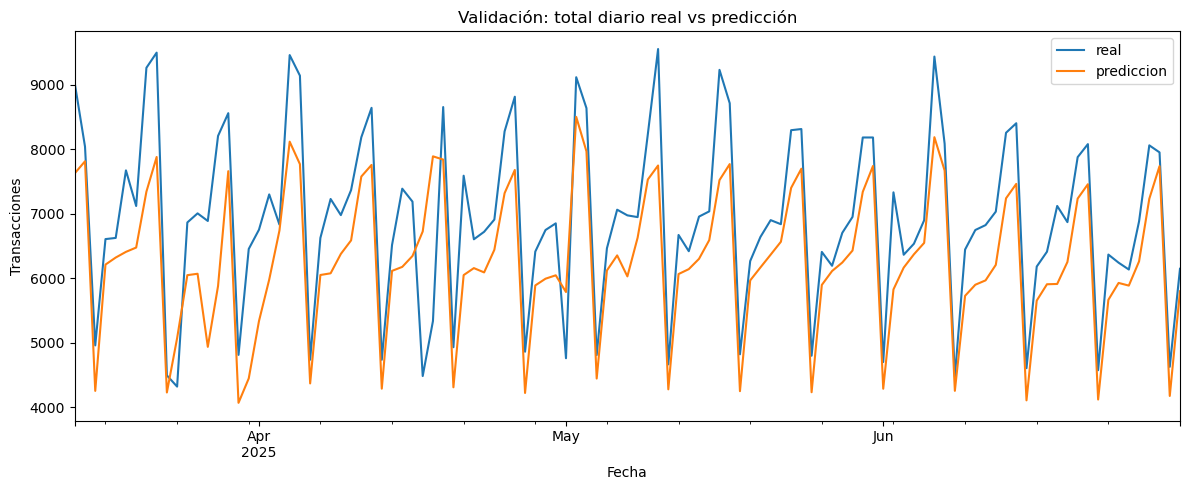

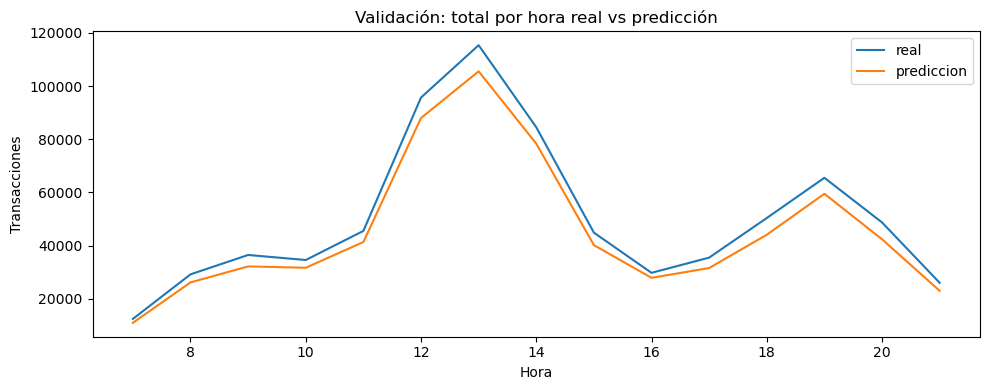

In [28]:
comparacion_diaria = (
    validacion_final
    .groupby("fecha", as_index=False)
    .agg(
        real=(TARGET_COLUMN, "sum"),
        prediccion=("prediccion", "sum"),
    )
)

comparacion_diaria.plot(
    x="fecha",
    y=["real", "prediccion"],
    figsize=(12, 5),
    title="Validación: total diario real vs predicción",
)
plt.xlabel("Fecha")
plt.ylabel("Transacciones")
plt.tight_layout()
plt.show()

comparacion_por_hora = (
    validacion_final
    .groupby("hora", as_index=False)
    .agg(
        real=(TARGET_COLUMN, "sum"),
        prediccion=("prediccion", "sum"),
    )
)

comparacion_por_hora.plot(
    x="hora",
    y=["real", "prediccion"],
    figsize=(10, 4),
    title="Validación: total por hora real vs predicción",
)
plt.xlabel("Hora")
plt.ylabel("Transacciones")
plt.tight_layout()
plt.show()


## 9. Función para consultar proyección por estación, día y hora

Esta es la función que genera la salida que necesitas: una fila por cada fecha, hora y estación.

In [30]:
def construir_frame_proyeccion(
    fecha_inicio: str | date,
    fecha_fin: str | date,
    horas: list[int] | None = None,
    estaciones: list[str] | None = None,
) -> pd.DataFrame:
    fecha_inicio = pd.to_datetime(fecha_inicio).date()
    fecha_fin = pd.to_datetime(fecha_fin).date()

    if fecha_fin < fecha_inicio:
        raise ValueError("fecha_fin no puede ser menor que fecha_inicio")

    horas = dataset.horas if horas is None else sorted(int(h) for h in horas)
    estaciones = dataset.estaciones if estaciones is None else sorted(str(e) for e in estaciones)
    fechas = pd.date_range(fecha_inicio, fecha_fin, freq="D")

    index = pd.MultiIndex.from_product(
        [fechas, horas, estaciones],
        names=["fecha", "hora", "estacion"],
    )
    frame = index.to_frame(index=False)
    return add_calendar_features(frame)


def proyectar_transacciones(
    modelo_entrenado: Pipeline,
    fecha_inicio: str | date,
    fecha_fin: str | date,
    horas: list[int] | None = None,
    estaciones: list[str] | None = None,
    redondear: bool = True,
) -> pd.DataFrame:
    frame = construir_frame_proyeccion(
        fecha_inicio=fecha_inicio,
        fecha_fin=fecha_fin,
        horas=horas,
        estaciones=estaciones,
    )
    pred = modelo_entrenado.predict(select_features(frame)).astype(float)
    pred = np.clip(pred, a_min=0, a_max=None)

    salida = frame[["fecha", "dia_semana_nombre", "hora", "estacion"]].copy()
    salida["transacciones_estimadas"] = pred

    if redondear:
        salida["transacciones_estimadas"] = salida["transacciones_estimadas"].round().astype(int)
    else:
        salida["transacciones_estimadas"] = salida["transacciones_estimadas"].round(2)

    salida["fecha"] = salida["fecha"].dt.date
    return salida.sort_values(["fecha", "hora", "estacion"]).reset_index(drop=True)


def consultar_proyeccion_semana(
    fecha_inicio: str | date,
    modelo_entrenado: Pipeline | None = None,
    horas: list[int] | None = None,
    estaciones: list[str] | None = None,
) -> pd.DataFrame:
    if modelo_entrenado is None:
        modelo_entrenado = modelo_final

    fecha_inicio_dt = pd.to_datetime(fecha_inicio).date()
    fecha_fin_dt = fecha_inicio_dt + timedelta(days=6)
    return proyectar_transacciones(
        modelo_entrenado=modelo_entrenado,
        fecha_inicio=fecha_inicio_dt,
        fecha_fin=fecha_fin_dt,
        horas=horas,
        estaciones=estaciones,
        redondear=True,
    )


## 10. Prueba: proyección de una semana

Ejemplo: semana que inicia el lunes 1 de junio de 2026. La salida contiene las transacciones estimadas por estación para cada día y cada hora.

In [32]:
proyeccion_semana = consultar_proyeccion_semana(FECHA_INICIO_PRUEBA)

print("Filas proyectadas:", len(proyeccion_semana))
print("Rango proyectado:", proyeccion_semana["fecha"].min(), "a", proyeccion_semana["fecha"].max())
print("Horas:", sorted(proyeccion_semana["hora"].unique().tolist()))
print("Estaciones:", sorted(proyeccion_semana["estacion"].unique().tolist()))

display(proyeccion_semana.head(40))

Filas proyectadas: 1575
Rango proyectado: 2026-06-01 a 2026-06-07
Horas: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Estaciones: ['Bebidas', 'Café', 'Caja', 'Cocina caliente', 'Cocina fría', 'Ensamble', 'Freidora', 'Horno', 'Panadería', 'Parrilla', 'Pasta', 'Pastelería', 'Plancha', 'Postres fríos', 'Salsas']


,fecha,dia_semana_nombre,hora,estacion,transacciones_estimadas
0,2026-06-01,lunes,7,Bebidas,6
1,2026-06-01,lunes,7,Café,16
2,2026-06-01,lunes,7,Caja,40
3,2026-06-01,lunes,7,Cocina caliente,5
4,2026-06-01,lunes,7,Cocina fría,7
5,2026-06-01,lunes,7,Ensamble,3
6,2026-06-01,lunes,7,Freidora,1
7,2026-06-01,lunes,7,Horno,0
8,2026-06-01,lunes,7,Panadería,3
9,2026-06-01,lunes,7,Parrilla,1


## 11. Ejemplo específico: lunes 1 de junio a las 8:00

Esta celda muestra exactamente el caso que mencionaste: cuántas transacciones se estiman a las 8 para cada estación.

In [34]:
fecha_ejemplo = pd.to_datetime(FECHA_INICIO_PRUEBA).date()
hora_ejemplo = 8

ejemplo_lunes_8 = proyeccion_semana[
    (proyeccion_semana["fecha"] == fecha_ejemplo)
    & (proyeccion_semana["hora"] == hora_ejemplo)
].sort_values("estacion")

print(f"Proyección para {fecha_ejemplo} a las {hora_ejemplo}:00")
display(ejemplo_lunes_8)

Proyección para 2026-06-01 a las 8:00


,fecha,dia_semana_nombre,hora,estacion,transacciones_estimadas
15,2026-06-01,lunes,8,Bebidas,18
16,2026-06-01,lunes,8,Café,39
17,2026-06-01,lunes,8,Caja,97
18,2026-06-01,lunes,8,Cocina caliente,11
19,2026-06-01,lunes,8,Cocina fría,16
20,2026-06-01,lunes,8,Ensamble,5
21,2026-06-01,lunes,8,Freidora,2
22,2026-06-01,lunes,8,Horno,0
23,2026-06-01,lunes,8,Panadería,8
24,2026-06-01,lunes,8,Parrilla,1


## 12. Vista tipo matriz: filas por fecha/hora y columnas por estación

Esta vista es útil para operación, porque permite ver todas las estaciones lado a lado por hora.

In [36]:
matriz_semana = proyeccion_semana.pivot_table(
    index=["fecha", "dia_semana_nombre", "hora"],
    columns="estacion",
    values="transacciones_estimadas",
    aggfunc="sum",
    fill_value=0,
).reset_index()

# Quita el nombre visual de columnas para que se vea más limpio.
matriz_semana.columns.name = None

display(matriz_semana.head(60))

,fecha,dia_semana_nombre,hora,Bebidas,Café,Caja,Cocina caliente,Cocina fría,Ensamble,Freidora,Horno,Panadería,Parrilla,Pasta,Pastelería,Plancha,Postres fríos,Salsas
0,2026-06-01,lunes,7,6,16,40,5,7,3,1,0,3,1,1,0,6,0,0
1,2026-06-01,lunes,8,18,39,97,11,16,5,2,0,8,1,1,0,14,0,0
2,2026-06-01,lunes,9,23,49,112,14,19,6,2,0,10,1,1,0,18,0,0
3,2026-06-01,lunes,10,22,34,105,18,20,14,5,1,7,4,3,1,14,0,0
4,2026-06-01,lunes,11,24,18,125,32,34,46,17,2,3,11,9,1,11,1,1
5,2026-06-01,lunes,12,42,6,230,89,80,135,53,4,1,36,26,4,17,2,1
6,2026-06-01,lunes,13,47,4,279,108,97,163,64,5,1,44,34,6,19,3,2
7,2026-06-01,lunes,14,36,3,198,74,63,115,43,4,1,29,21,6,13,3,1
8,2026-06-01,lunes,15,23,5,111,34,32,53,18,3,1,14,9,4,7,2,1
9,2026-06-01,lunes,16,18,9,83,19,14,28,9,4,2,8,4,5,6,2,1


## 13. Guardar la proyección y el modelo

Se guarda:

- el modelo entrenado como `.joblib`
- la proyección semanal como `.csv`

In [38]:
joblib.dump(
    {
        "modelo": modelo_final,
        "nombre_modelo_final": nombre_modelo_final,
        "feature_numeric_columns": FEATURE_NUMERIC_COLUMNS,
        "feature_categorical_columns": FEATURE_CATEGORICAL_COLUMNS,
        "estaciones": dataset.estaciones,
        "horas": dataset.horas,
        "fecha_inicio_entrenamiento": dataset.fecha_inicio.isoformat(),
        "fecha_fin_entrenamiento": dataset.fecha_fin.isoformat(),
        "metricas_modelo_final": metricas_modelo_final,
        "comparacion_modelos": comparacion_modelos.to_dict(orient="records"),
    },
    RUTA_MODELO,
    compress=3,
)

proyeccion_semana.to_csv(RUTA_PROYECCION_SEMANA, index=False, encoding="utf-8-sig")
comparacion_modelos.to_csv(RUTA_COMPARACION_MODELOS, index=False, encoding="utf-8-sig")
evaluacion_por_estacion.to_csv(RUTA_EVALUACION_ESTACION, index=False, encoding="utf-8-sig")
evaluacion_por_hora.to_csv(RUTA_EVALUACION_HORA, index=False, encoding="utf-8-sig")

print("Modelo final guardado en:", RUTA_MODELO.resolve())
print("Proyección semanal guardada en:", RUTA_PROYECCION_SEMANA.resolve())
print("Comparación de modelos guardada en:", RUTA_COMPARACION_MODELOS.resolve())
print("Evaluación por estación guardada en:", RUTA_EVALUACION_ESTACION.resolve())
print("Evaluación por hora guardada en:", RUTA_EVALUACION_HORA.resolve())


Modelo final guardado en: C:\Users\andre\modelo_transacciones_estacion_hora.joblib
Proyección semanal guardada en: C:\Users\andre\proyeccion_semana_estacion_hora.csv
Comparación de modelos guardada en: C:\Users\andre\comparacion_modelos.csv
Evaluación por estación guardada en: C:\Users\andre\evaluacion_por_estacion.csv
Evaluación por hora guardada en: C:\Users\andre\evaluacion_por_hora.csv


## 14. Cargar el modelo guardado y consultar otra semana

Esta celda simula el uso posterior del modelo ya entrenado.

In [40]:
artefacto = joblib.load(RUTA_MODELO)
modelo_cargado = artefacto["modelo"]

print("Modelo cargado:", artefacto.get("nombre_modelo_final"))
print("Métricas guardadas:")
display(pd.DataFrame([artefacto.get("metricas_modelo_final", {})]))

# Cambia esta fecha para consultar cualquier semana.
otra_fecha_inicio = "2026-06-08"
proyeccion_otra_semana = consultar_proyeccion_semana(otra_fecha_inicio, modelo_entrenado=modelo_cargado)

display(proyeccion_otra_semana.head(40))


Modelo cargado: mejor_modelo_busqueda
Métricas guardadas:


,mae,rmse,wmape,smape,r2
0,5.225306,10.167969,0.169865,0.460316,0.959825


,fecha,dia_semana_nombre,hora,estacion,transacciones_estimadas
0,2026-06-08,lunes,7,Bebidas,6
1,2026-06-08,lunes,7,Café,17
2,2026-06-08,lunes,7,Caja,42
3,2026-06-08,lunes,7,Cocina caliente,5
4,2026-06-08,lunes,7,Cocina fría,7
5,2026-06-08,lunes,7,Ensamble,3
6,2026-06-08,lunes,7,Freidora,1
7,2026-06-08,lunes,7,Horno,0
8,2026-06-08,lunes,7,Panadería,3
9,2026-06-08,lunes,7,Parrilla,1


## 15. Consultas útiles

Puedes filtrar por estación, por hora o por fecha.

In [42]:
# Ejemplo 1: Solo una estación
estacion_a_consultar = dataset.estaciones[0]
display(proyeccion_semana[proyeccion_semana["estacion"] == estacion_a_consultar].head(30))

# Ejemplo 2: Solo una hora en toda la semana
hora_a_consultar = 8
display(proyeccion_semana[proyeccion_semana["hora"] == hora_a_consultar].head(30))

# Ejemplo 3: Total por estación para la semana completa
total_semana_por_estacion = (
    proyeccion_semana.groupby("estacion", as_index=False)["transacciones_estimadas"]
    .sum()
    .sort_values("transacciones_estimadas", ascending=False)
)
display(total_semana_por_estacion)

,fecha,dia_semana_nombre,hora,estacion,transacciones_estimadas
0,2026-06-01,lunes,7,Bebidas,6
15,2026-06-01,lunes,8,Bebidas,18
30,2026-06-01,lunes,9,Bebidas,23
45,2026-06-01,lunes,10,Bebidas,22
60,2026-06-01,lunes,11,Bebidas,24
75,2026-06-01,lunes,12,Bebidas,42
90,2026-06-01,lunes,13,Bebidas,47
105,2026-06-01,lunes,14,Bebidas,36
120,2026-06-01,lunes,15,Bebidas,23
135,2026-06-01,lunes,16,Bebidas,18


,fecha,dia_semana_nombre,hora,estacion,transacciones_estimadas
15,2026-06-01,lunes,8,Bebidas,18
16,2026-06-01,lunes,8,Café,39
17,2026-06-01,lunes,8,Caja,97
18,2026-06-01,lunes,8,Cocina caliente,11
19,2026-06-01,lunes,8,Cocina fría,16
20,2026-06-01,lunes,8,Ensamble,5
21,2026-06-01,lunes,8,Freidora,2
22,2026-06-01,lunes,8,Horno,0
23,2026-06-01,lunes,8,Panadería,8
24,2026-06-01,lunes,8,Parrilla,1


,estacion,transacciones_estimadas
2,Caja,15821
5,Ensamble,7064
3,Cocina caliente,4613
4,Cocina fría,3811
0,Bebidas,2938
6,Freidora,2435
9,Parrilla,1907
1,Café,1735
12,Plancha,1220
10,Pasta,1068


## 16. Gráfico rápido: total estimado por estación en la semana

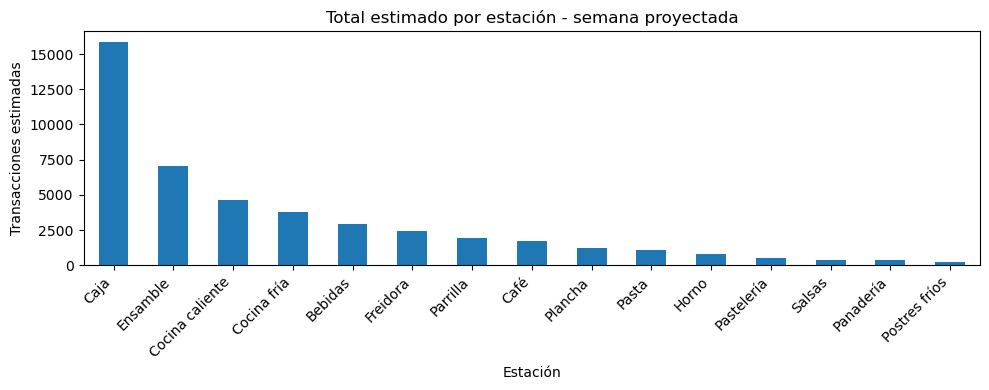

In [44]:
total_semana_por_estacion.plot(kind="bar", x="estacion", y="transacciones_estimadas", figsize=(10, 4), legend=False)
plt.title("Total estimado por estación - semana proyectada")
plt.xlabel("Estación")
plt.ylabel("Transacciones estimadas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Notas de ajuste

- Si quieres proyectar solo ciertas horas, llama `consultar_proyeccion_semana(..., horas=[8, 9, 10])`.
- Si quieres proyectar solo ciertas estaciones, llama `consultar_proyeccion_semana(..., estaciones=["Cocina caliente", "Parrilla"])`.
- Si un item aparece en el histórico pero no está en el archivo de estaciones, el notebook lo agrupa en `SIN_ESTACION_MAPEADA` para que no se pierdan ventas.
- Si una venta de un item debe repartirse entre estaciones en vez de contarse completa en cada estación, habría que agregar pesos por estación al archivo de mapeo.

In [46]:
from datetime import date, timedelta
import pandas as pd

# Calcular automáticamente el próximo lunes
hoy = date.today()
dias_hasta_proximo_lunes = (7 - hoy.weekday()) % 7

# Si hoy es lunes, toma el lunes siguiente, no hoy
if dias_hasta_proximo_lunes == 0:
    dias_hasta_proximo_lunes = 7

inicio_proxima_semana = hoy + timedelta(days=dias_hasta_proximo_lunes)

print("Inicio de la próxima semana:", inicio_proxima_semana)

proyeccion_proxima_semana = consultar_proyeccion_semana(inicio_proxima_semana)

display(proyeccion_proxima_semana)

Inicio de la próxima semana: 2026-06-01


,fecha,dia_semana_nombre,hora,estacion,transacciones_estimadas
0,2026-06-01,lunes,7,Bebidas,6
1,2026-06-01,lunes,7,Café,16
2,2026-06-01,lunes,7,Caja,40
3,2026-06-01,lunes,7,Cocina caliente,5
4,2026-06-01,lunes,7,Cocina fría,7
...,...,...,...,...,...
1570,2026-06-07,domingo,21,Pasta,0
1571,2026-06-07,domingo,21,Pastelería,0
1572,2026-06-07,domingo,21,Plancha,0
1573,2026-06-07,domingo,21,Postres fríos,0


In [47]:
proyeccion_proxima_semana.to_csv(
    "proyeccion_proxima_semana_estacion_hora.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivo guardado: proyeccion_proxima_semana_estacion_hora.csv")

Archivo guardado: proyeccion_proxima_semana_estacion_hora.csv
